In [3]:
"""
Notebook 02 — Feature Engineering
=================================
Objectif : partir du dataset consolidé (Parquet 115 Mo, 1.8M lignes)
et créer les features prédictives pour le modèle.

Contrainte critique : toutes les features doivent être disponibles
au moment de l'appel (T=0) — pas de data leakage.
"""

import pandas as pd
import numpy as np
from pathlib import Path
import time
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# Chemins
project_root = Path('..').resolve()
PROCESSED_DIR = project_root / 'data' / 'processed'
parquet_path = PROCESSED_DIR / 'lfb_merged_2009_2026.parquet'

# Rechargement du dataset consolidé
print(f"📂 Chargement du Parquet consolidé...")
start = time.time()
df = pd.read_parquet(parquet_path)
elapsed = time.time() - start

print(f"✅ Chargé en {elapsed:.1f}s")
print(f"   Shape       : {df.shape}")
print(f"   Mémoire     : {df.memory_usage(deep=True).sum() / 1e6:.0f} Mo")
print(f"   Période     : {df['CalYear'].min()} → {df['CalYear'].max()}")
print(f"   Target médiane : {df['AttendanceTimeMinutes'].median():.2f} min")

📂 Chargement du Parquet consolidé...
✅ Chargé en 0.9s
   Shape       : (1816534, 50)
   Mémoire     : 1224 Mo
   Période     : 2009 → 2026
   Target médiane : 4.98 min


# 🔥 Notebook 02 — Feature Engineering

## Objectif
À partir du dataset consolidé LFB (2009-2026, 1.8M lignes), créer les features prédictives pour le modèle de temps de réponse.

## Contrainte critique : pas de data leakage
Toutes les features utilisées par le modèle doivent être **disponibles au moment de l'appel** (T=0). Les colonnes contenant des infos post-appel (véhicule assigné, station déployée, timestamps post-mobilisation) ne peuvent servir **que** pour créer des **statistiques historiques agrégées** — jamais comme features directes.

## Familles de features à créer
1. **Temporelles** : heure, jour, mois, weekend, holiday, encodages cycliques
2. **Géographiques** : borough, ward, coordonnées → distance aux stations proches
3. **Incident** : type déclaré, catégorie de propriété
4. **Historiques agrégées** ⭐ : moyennes de temps de réponse par borough × heure × type (calculées uniquement sur le passé)
5. **Contextuelles** (bonus) : jours fériés UK, météo

In [8]:
"""
=== FEATURE ENGINEERING #1 : TEMPOREL ===
Toutes ces features sont disponibles à T=0 (moment de l'appel).
"""

# --- 1. Parsing des timestamps ---
df['CallDateTime'] = pd.to_datetime(
    df['DateOfCall'].dt.strftime('%Y-%m-%d') + ' ' + df['TimeOfCall'].astype(str),
    errors='coerce'
)
print(f"CallDateTime parsé : {df['CallDateTime'].notna().sum():,} / {len(df):,}")

# --- 2. Features calendaires basiques ---
df['hour']         = df['CallDateTime'].dt.hour
df['day_of_week']  = df['CallDateTime'].dt.dayofweek
df['day_of_month'] = df['CallDateTime'].dt.day
df['month']        = df['CallDateTime'].dt.month
df['quarter']      = df['CallDateTime'].dt.quarter
df['year']         = df['CallDateTime'].dt.year

# --- 3. Features métier binaires ---
df['is_weekend']    = (df['day_of_week'] >= 5).astype(int)
df['is_night']      = df['hour'].isin([0,1,2,3,4,5,22,23]).astype(int)
df['is_rush_hour']  = df['hour'].isin([7,8,9,17,18,19]).astype(int)
df['is_summer']     = df['month'].isin([6,7,8]).astype(int)
df['is_winter']     = df['month'].isin([12,1,2]).astype(int)

# --- 4. Encodage cyclique ---
df['hour_sin']  = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['dow_sin']   = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']   = np.cos(2 * np.pi * df['day_of_week'] / 7)

# --- Récap ---
temporal_features = [
    'hour', 'day_of_week', 'day_of_month', 'month', 'quarter', 'year',
    'is_weekend', 'is_night', 'is_rush_hour', 'is_summer', 'is_winter',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos'
]
print(f"\n✅ {len(temporal_features)} features temporelles créées")

CallDateTime parsé : 1,816,534 / 1,816,534

✅ 17 features temporelles créées


In [9]:
"""
Vérification de la PERTINENCE des features temporelles.
Si une feature n'a AUCUN impact sur la target, elle ne servira à rien au modèle.
"""

print("=== Impact HEURE sur AttendanceTimeMinutes ===")
by_hour = df.groupby('hour')['AttendanceTimeMinutes'].agg(['mean', 'median', 'count']).round(2)
print(by_hour)

print("\n=== Impact WEEKEND sur AttendanceTimeMinutes ===")
print(df.groupby('is_weekend')['AttendanceTimeMinutes'].agg(['mean', 'median', 'count']).round(2))

print("\n=== Impact NIGHT sur AttendanceTimeMinutes ===")
print(df.groupby('is_night')['AttendanceTimeMinutes'].agg(['mean', 'median', 'count']).round(2))

print("\n=== Impact RUSH HOUR sur AttendanceTimeMinutes ===")
print(df.groupby('is_rush_hour')['AttendanceTimeMinutes'].agg(['mean', 'median', 'count']).round(2))

=== Impact HEURE sur AttendanceTimeMinutes ===
      mean  median   count
hour                      
0     5.27    4.93   59795
1     5.42    5.08   49366
2     5.55    5.20   40444
3     5.58    5.23   35498
4     5.57    5.23   31751
5     5.54    5.20   30246
6     5.60    5.27   35127
7     5.31    4.97   48471
8     5.14    4.78   64768
9     5.04    4.72   78417
10    5.26    4.88   85427
11    5.53    5.12   91223
12    5.58    5.18   94141
13    5.53    5.13   96777
14    5.59    5.15   96719
15    5.64    5.20   98023
16    5.57    5.13  101382
17    5.54    5.10  108035
18    5.43    5.02  111437
19    5.25    4.87  110032
20    5.09    4.73  103243
21    5.05    4.70   93117
22    5.01    4.67   82378
23    5.06    4.73   70717

=== Impact WEEKEND sur AttendanceTimeMinutes ===
            mean  median    count
is_weekend                       
0           5.39    5.00  1290864
1           5.31    4.93   525670

=== Impact NIGHT sur AttendanceTimeMinutes ===
          mean  m

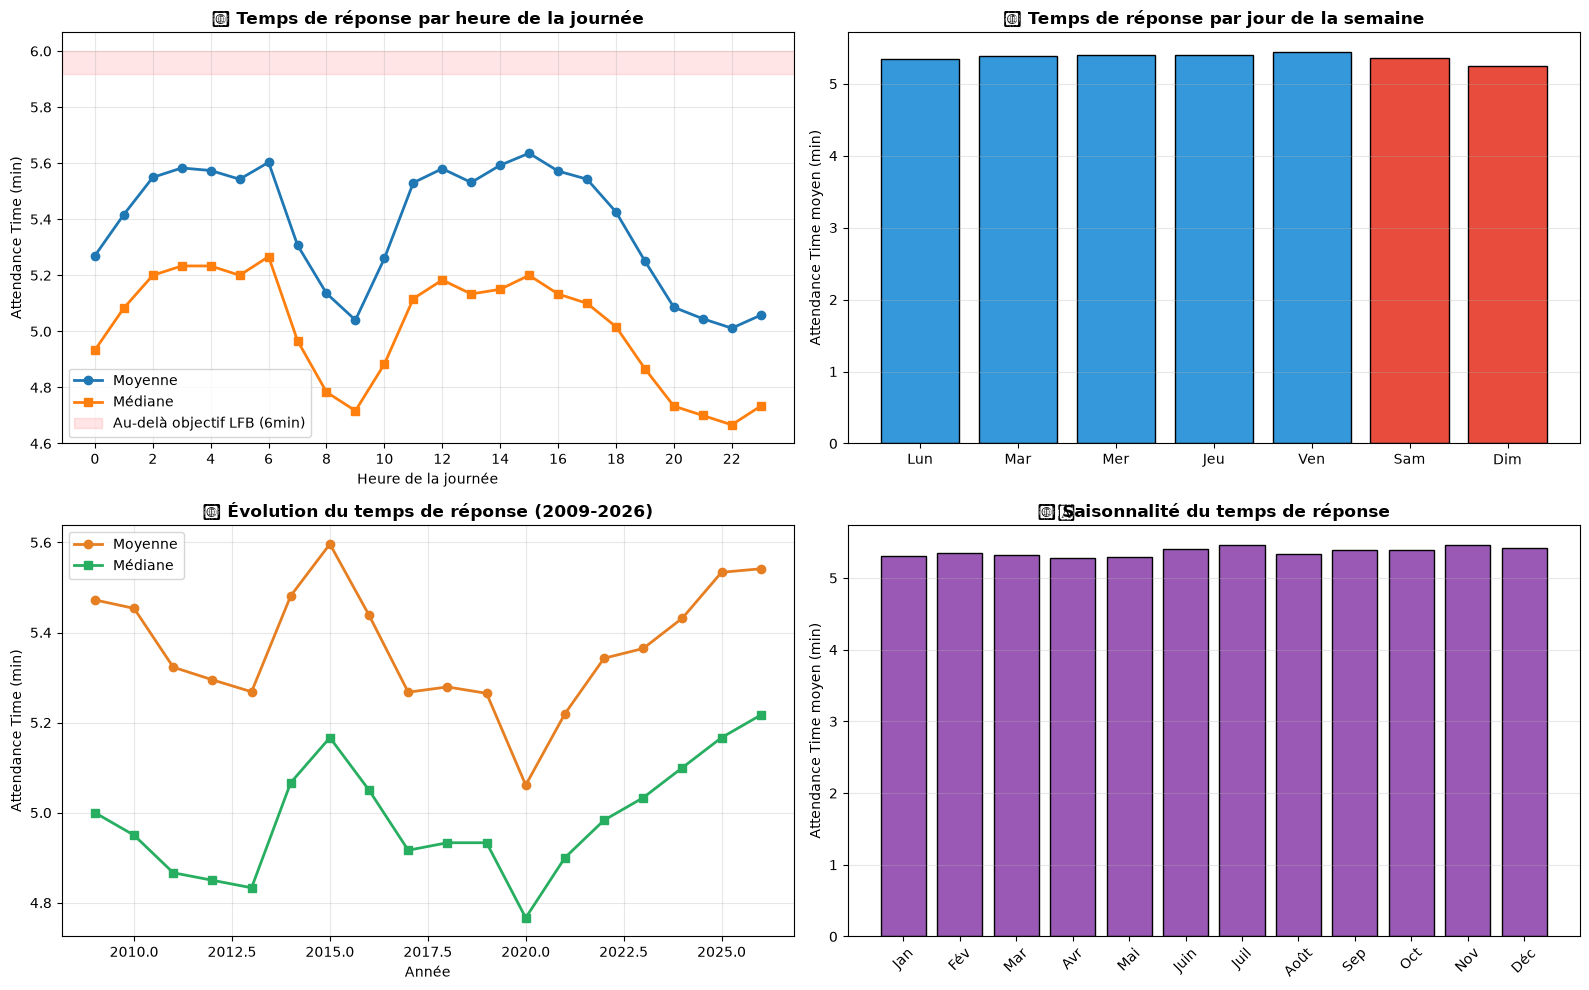

✅ Graphique sauvegardé dans reports/temporal_patterns.png


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Temps de réponse par heure de la journée
by_hour_stats = df.groupby('hour')['AttendanceTimeMinutes'].agg(['mean', 'median'])
axes[0,0].plot(by_hour_stats.index, by_hour_stats['mean'], marker='o', label='Moyenne', linewidth=2)
axes[0,0].plot(by_hour_stats.index, by_hour_stats['median'], marker='s', label='Médiane', linewidth=2)
axes[0,0].axhspan(6, by_hour_stats['mean'].max()*1.05, alpha=0.1, color='red', label='Au-delà objectif LFB (6min)')
axes[0,0].set_xlabel('Heure de la journée')
axes[0,0].set_ylabel('Attendance Time (min)')
axes[0,0].set_title('🕐 Temps de réponse par heure de la journée', fontweight='bold')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)
axes[0,0].set_xticks(range(0, 24, 2))

# 2. Temps de réponse par jour de la semaine
days = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']
by_dow = df.groupby('day_of_week')['AttendanceTimeMinutes'].mean()
colors_dow = ['#3498db']*5 + ['#e74c3c']*2  # bleu semaine, rouge weekend
axes[0,1].bar(days, by_dow.values, color=colors_dow, edgecolor='black')
axes[0,1].set_ylabel('Attendance Time moyen (min)')
axes[0,1].set_title('📅 Temps de réponse par jour de la semaine', fontweight='bold')
axes[0,1].grid(True, alpha=0.3, axis='y')

# 3. Évolution annuelle
by_year = df.groupby('year')['AttendanceTimeMinutes'].agg(['mean', 'median'])
axes[1,0].plot(by_year.index, by_year['mean'], marker='o', label='Moyenne', linewidth=2, color='#e67e22')
axes[1,0].plot(by_year.index, by_year['median'], marker='s', label='Médiane', linewidth=2, color='#27ae60')
axes[1,0].set_xlabel('Année')
axes[1,0].set_ylabel('Attendance Time (min)')
axes[1,0].set_title('📈 Évolution du temps de réponse (2009-2026)', fontweight='bold')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 4. Temps de réponse par mois (saisonnalité)
months_labels = ['Jan','Fév','Mar','Avr','Mai','Juin','Juil','Août','Sep','Oct','Nov','Déc']
by_month = df.groupby('month')['AttendanceTimeMinutes'].mean()
axes[1,1].bar(months_labels, by_month.values, color='#9b59b6', edgecolor='black')
axes[1,1].set_ylabel('Attendance Time moyen (min)')
axes[1,1].set_title('🌤️ Saisonnalité du temps de réponse', fontweight='bold')
axes[1,1].grid(True, alpha=0.3, axis='y')
plt.setp(axes[1,1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig(project_root / 'reports' / 'temporal_patterns.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé dans reports/temporal_patterns.png")

In [11]:
"""
=== FEATURE ENGINEERING #2 : GÉOGRAPHIE ===
La géographie est LE driver principal du temps de réponse :
distance station <-> incident + densité urbaine.
"""

# 1. Combien de boroughs uniques ?
print(f"=== Répartition géographique ===")
print(f"Boroughs uniques      : {df['IncGeo_BoroughName'].nunique()}")
print(f"Wards uniques         : {df['IncGeo_WardName'].nunique()}")
print(f"Postcodes districts   : {df['Postcode_district'].nunique()}")
print(f"Stations déployées    : {df['DeployedFromStation_Name'].nunique()}")

# 2. Impact BOROUGH sur target
print(f"\n=== TOP 10 BOROUGHS - Plus rapides ===")
borough_stats = df.groupby('IncGeo_BoroughName')['AttendanceTimeMinutes'].agg(['mean', 'median', 'count']).round(2)
borough_stats = borough_stats[borough_stats['count'] >= 1000]  # au moins 1000 incidents pour être significatif
print(borough_stats.nsmallest(10, 'mean'))

print(f"\n=== TOP 10 BOROUGHS - Plus lents ===")
print(borough_stats.nlargest(10, 'mean'))

# 3. Amplitude géographique
print(f"\n=== AMPLITUDE GÉOGRAPHIQUE ===")
print(f"Écart entre borough le + rapide et le + lent : {borough_stats['mean'].max() - borough_stats['mean'].min():.2f} min")
print(f"Ratio                                        : {borough_stats['mean'].max() / borough_stats['mean'].min():.2f}×")

=== Répartition géographique ===
Boroughs uniques      : 33
Wards uniques         : 1480
Postcodes districts   : 329
Stations déployées    : 118

=== TOP 10 BOROUGHS - Plus rapides ===
                        mean  median  count
IncGeo_BoroughName                         
KENSINGTON AND CHELSEA  4.55    4.23  57592
LAMBETH                 4.67    4.35  76582
TOWER HAMLETS           4.69    4.33  78284
ISLINGTON               4.83    4.53  58362
CITY OF LONDON          4.85    4.52  19261
CAMDEN                  4.93    4.60  85977
SOUTHWARK               4.94    4.63  80384
HACKNEY                 4.96    4.67  68783
LEWISHAM                5.00    4.70  64618
HAMMERSMITH AND FULHAM  5.03    4.73  51079

=== TOP 10 BOROUGHS - Plus lents ===
                      mean  median  count
IncGeo_BoroughName                       
HILLINGDON            6.44    6.05  60149
ENFIELD               6.18    5.72  55511
BROMLEY               6.16    5.80  52329
HAVERING              6.00    5.52  394

In [12]:
"""
=== FEATURE ENGINEERING #2 : GÉOGRAPHIE ===
On encode 3 informations complémentaires pour chaque borough :
1. borough_target_encoded : moyenne historique du temps de réponse
2. borough_freq           : volumétrie d'incidents (proxy de densité)
3. borough_center_flag    : est-ce dans le "cœur" de Londres ?

⚠️ Anti-leakage : dans un vrai split train/test, ces encodings 
devront être calculés UNIQUEMENT sur le train. Pour l'instant on 
prototype sur tout le dataset, on refera proprement avant le modèle.
"""

# --- 1. Nettoyage préalable : uniformiser la casse ---
df['borough'] = df['IncGeo_BoroughName'].str.upper().str.strip()

# --- 2. TARGET ENCODING : moyenne historique par borough ---
# Note : version simplifiée pour exploration, à recalculer proprement avec split temporel
borough_target = df.groupby('borough')['AttendanceTimeMinutes'].mean()
df['borough_target_enc'] = df['borough'].map(borough_target)

# --- 3. FREQUENCY ENCODING : volumétrie par borough ---
borough_freq = df['borough'].value_counts()
df['borough_freq'] = df['borough'].map(borough_freq)

# --- 4. CENTER FLAG : borough dans le cœur (top 10 les + rapides) ---
inner_boroughs = borough_target.nsmallest(10).index.tolist()
df['is_inner_london'] = df['borough'].isin(inner_boroughs).astype(int)

# --- 5. TARGET ENCODING par postcode (plus granulaire) ---
# Regroupe les postcodes rares (< 500 incidents) sous "OTHER" pour éviter overfit
postcode_counts = df['Postcode_district'].value_counts()
frequent_postcodes = postcode_counts[postcode_counts >= 500].index
df['postcode_group'] = df['Postcode_district'].where(df['Postcode_district'].isin(frequent_postcodes), 'OTHER')

postcode_target = df.groupby('postcode_group')['AttendanceTimeMinutes'].mean()
df['postcode_target_enc'] = df['postcode_group'].map(postcode_target)

# --- 6. Vérif ---
geo_features = ['borough_target_enc', 'borough_freq', 'is_inner_london', 'postcode_target_enc']
print(f"✅ {len(geo_features)} features géographiques créées\n")

print(f"=== Répartition inner vs outer London ===")
print(df.groupby('is_inner_london')['AttendanceTimeMinutes'].agg(['mean', 'median', 'count']).round(2))

print(f"\n=== Postcodes fréquents (>500 incidents) : {len(frequent_postcodes)} sur {postcode_counts.count()} ===")
print(f"=== Amplitude postcode target encoding ===")
print(f"Postcode le + rapide : {postcode_target.min():.2f} min")
print(f"Postcode le + lent   : {postcode_target.max():.2f} min")
print(f"Amplitude            : {postcode_target.max() - postcode_target.min():.2f} min")

✅ 4 features géographiques créées

=== Répartition inner vs outer London ===
                 mean  median    count
is_inner_london                       
0                5.65    5.27  1175612
1                4.85    4.53   640922

=== Postcodes fréquents (>500 incidents) : 271 sur 329 ===
=== Amplitude postcode target encoding ===
Postcode le + rapide : 3.91 min
Postcode le + lent   : 8.57 min
Amplitude            : 4.66 min


In [13]:
# Aperçu sur 5 lignes
print("=== APERÇU FEATURES GÉO ===")
print(df[['borough', 'is_inner_london', 'borough_target_enc', 'borough_freq',
          'Postcode_district', 'postcode_target_enc', 'AttendanceTimeMinutes']].head())

# Corrélation attendue avec la target
print(f"\n=== CORRÉLATIONS AVEC LA TARGET ===")
for col in geo_features:
    corr = df[col].corr(df['AttendanceTimeMinutes'])
    print(f"  {col:<25} : {corr:+.4f}")

=== APERÇU FEATURES GÉO ===
      borough  is_inner_london  borough_target_enc  borough_freq Postcode_district  postcode_target_enc  AttendanceTimeMinutes
0  WANDSWORTH                0            5.084145         56995              SW11             4.523120               5.316667
1     ENFIELD                0            6.179308         55511                N9             5.249033               5.133333
2  HILLINGDON                0            6.444761         60149              UB10             5.728923               3.500000
3   ISLINGTON                1            4.833884         58362                N7             4.820161               3.883333
4      CAMDEN                1            4.934888         85977               NW5             4.565341               2.866667

=== CORRÉLATIONS AVEC LA TARGET ===
  borough_target_enc        : +0.2200
  borough_freq              : -0.0906
  is_inner_london           : -0.1700
  postcode_target_enc       : +0.3250


In [14]:
"""
=== FEATURE ENGINEERING #3 : DISTANCE AUX CASERNES ===
Étape 1 : identifier les 118 stations et vérifier qu'on peut les géocoder.
"""

# Liste unique des stations déployées historiquement
stations = df['DeployedFromStation_Name'].value_counts()

print(f"=== Stations déployées : {len(stations)} ===\n")
print("=== TOP 20 stations les plus actives ===")
print(stations.head(20))

print(f"\n=== BOTTOM 20 stations (peut-être fermées/rares) ===")
print(stations.tail(20))

# Est-ce qu'on a `Easting_m` / `Northing_m` (coordonnées british national grid) ?
print(f"\n=== Coordonnées disponibles côté INCIDENTS ? ===")
print(f"Easting_m non-null : {df['Easting_m'].notna().sum():,} / {len(df):,}")
print(f"Northing_m non-null : {df['Northing_m'].notna().sum():,} / {len(df):,}")
print(f"Easting_rounded non-null : {df['Easting_rounded'].notna().sum():,}")

=== Stations déployées : 118 ===

=== TOP 20 stations les plus actives ===
DeployedFromStation_Name
Soho                59098
Paddington          39267
Euston              35247
Lambeth             32652
Hammersmith         30288
North Kensington    30014
Tottenham           29239
Kentish Town        28541
West Hampstead      28499
Brixton             28354
Ilford              27279
Croydon             27038
Shoreditch          27028
Stoke Newington     26563
Chelsea             25856
Plumstead           23838
Bethnal Green       22872
Homerton            22379
Enfield             22229
Poplar              22204
Name: count, dtype: int64

=== BOTTOM 20 stations (peut-être fermées/rares) ===
DeployedFromStation_Name
Clerkenwell        7420
Purley             7408
Hainault           6445
Westminster        5744
Southwark          5401
Wennington         4782
Belsize            4621
Kingsland          4151
Knightsbridge      3768
Bow                3660
Woolwich           3110
Downham    

In [15]:
"""
=== FEATURE ENGINEERING #3 : DISTANCE AUX STATIONS ===
Étape 1 : calculer les coordonnées de chaque station via ses incidents historiques.
"""

# Filtre : on ne garde que les stations avec au moins 100 incidents (élimine les fantômes)
station_activity = df['DeployedFromStation_Name'].value_counts()
active_stations = station_activity[station_activity >= 100].index.tolist()

print(f"✅ Stations actives retenues : {len(active_stations)} / {len(station_activity)}")
print(f"   (filtre : >= 100 incidents historiques)")

# Barycentre = moyenne des Easting_rounded / Northing_rounded des incidents dispatchés
station_coords = df[df['DeployedFromStation_Name'].isin(active_stations)].groupby('DeployedFromStation_Name').agg(
    easting=('Easting_rounded', 'mean'),
    northing=('Northing_rounded', 'mean'),
    n_incidents=('DeployedFromStation_Name', 'count')
).round(0)

print(f"\n=== Aperçu 10 stations avec coords ===")
print(station_coords.sort_values('n_incidents', ascending=False).head(10))

print(f"\n=== Bornes géographiques ===")
print(f"Easting  : {station_coords['easting'].min():.0f} → {station_coords['easting'].max():.0f}")
print(f"Northing : {station_coords['northing'].min():.0f} → {station_coords['northing'].max():.0f}")

✅ Stations actives retenues : 112 / 118
   (filtre : >= 100 incidents historiques)

=== Aperçu 10 stations avec coords ===
                           easting  northing  n_incidents
DeployedFromStation_Name                                 
Soho                      529532.0  181047.0        59098
Paddington                526483.0  182014.0        39267
Euston                    529444.0  182503.0        35247
Lambeth                   530434.0  178733.0        32652
Hammersmith               523348.0  179163.0        30288
North Kensington          524225.0  181745.0        30014
Tottenham                 533446.0  190102.0        29239
Kentish Town              528864.0  185238.0        28541
West Hampstead            525449.0  185116.0        28499
Brixton                   531256.0  175554.0        28354

=== Bornes géographiques ===
Easting  : 507169 → 554045
Northing : 160538 → 197388


In [16]:
"""
Étape 2 : pour chaque incident, calculer les distances aux stations.
"""

# On convertit les stations en array numpy pour vectorisation ultra-rapide
station_names = station_coords.index.values
station_east  = station_coords['easting'].values
station_north = station_coords['northing'].values

# Coordonnées de tous les incidents
inc_east  = df['Easting_rounded'].values
inc_north = df['Northing_rounded'].values

print(f"⏱️  Calcul de distances pour {len(inc_east):,} incidents × {len(station_names)} stations")
print(f"   (attendre ~30-60 sec)")

# Calcul vectorisé
start = time.time()

# Distance = sqrt((x_incident - x_station)² + (y_incident - y_station)²)
# On calcule pour toutes les paires (incident, station) en une fois
# Shape : (N_incidents, N_stations)
dx = inc_east[:, None]  - station_east[None, :]
dy = inc_north[:, None] - station_north[None, :]
distances = np.sqrt(dx**2 + dy**2)  # en mètres

print(f"✅ Matrice de distances calculée en {time.time()-start:.0f}s")
print(f"   Shape : {distances.shape}")

# Distance à la station la plus proche (m → km)
df['dist_nearest_station_km']    = distances.min(axis=1) / 1000
# Distance moyenne aux 3 plus proches
df['dist_top3_stations_km']      = np.partition(distances, 3, axis=1)[:, :3].mean(axis=1) / 1000
# Nombre de stations dans un rayon de 3 km
df['n_stations_within_3km']      = (distances <= 3000).sum(axis=1)

print(f"\n=== Distributions ===")
print(df[['dist_nearest_station_km', 'dist_top3_stations_km', 'n_stations_within_3km']].describe().round(2))

⏱️  Calcul de distances pour 1,816,534 incidents × 112 stations
   (attendre ~30-60 sec)
✅ Matrice de distances calculée en 8s
   Shape : (1816534, 112)

=== Distributions ===
       dist_nearest_station_km  dist_top3_stations_km  n_stations_within_3km
count               1816534.00             1816534.00             1816534.00
mean                      1.18                   2.19                   3.45
std                       0.67                   0.84                   2.33
min                       0.00                   0.88                   0.00
25%                       0.69                   1.53                   2.00
50%                       1.07                   2.10                   3.00
75%                       1.58                   2.70                   5.00
max                       7.58                   9.58                  11.00


In [17]:
"""
Étape 3 : vérifier que ces features sont bien prédictives.
"""

distance_features = ['dist_nearest_station_km', 'dist_top3_stations_km', 'n_stations_within_3km']

print("=== CORRÉLATIONS AVEC LA TARGET ===")
for col in distance_features:
    corr = df[col].corr(df['AttendanceTimeMinutes'])
    print(f"  {col:<30} : {corr:+.4f}")

# Analyse par bucket de distance
print(f"\n=== Impact distance station la plus proche ===")
df['dist_bucket'] = pd.cut(df['dist_nearest_station_km'], 
                            bins=[0, 1, 2, 3, 5, 100],
                            labels=['< 1 km', '1-2 km', '2-3 km', '3-5 km', '> 5 km'])
print(df.groupby('dist_bucket')['AttendanceTimeMinutes'].agg(['mean', 'median', 'count']).round(2))

=== CORRÉLATIONS AVEC LA TARGET ===
  dist_nearest_station_km        : +0.3681
  dist_top3_stations_km          : +0.2668
  n_stations_within_3km          : -0.1717

=== Impact distance station la plus proche ===
              mean  median   count
dist_bucket                       
< 1 km        4.67    4.23  828304
1-2 km        5.66    5.25  764692
2-3 km        6.82    6.43  200345
3-5 km        8.12    7.65   22483
> 5 km       10.48   10.03     710


In [18]:
"""
=== FEATURE ENGINEERING #4 : TYPE D'INCIDENT ===
Ces features sont disponibles à T=0 (déclarées au téléphone par l'appelant).
"""

# 1. Target encoding IncidentGroup
inc_group_target = df.groupby('IncidentGroup')['AttendanceTimeMinutes'].mean()
df['incident_group_target_enc'] = df['IncidentGroup'].map(inc_group_target)

# 2. Target encoding PropertyCategory
prop_cat_target = df.groupby('PropertyCategory')['AttendanceTimeMinutes'].mean()
df['property_cat_target_enc'] = df['PropertyCategory'].map(prop_cat_target)

# 3. Target encoding AddressQualifier (Home/Street/etc.)
addr_qual_target = df.groupby('AddressQualifier')['AttendanceTimeMinutes'].mean()
df['address_qual_target_enc'] = df['AddressQualifier'].map(addr_qual_target)

# Corrélations
print("=== CORRÉLATIONS FEATURES INCIDENT ===")
for col in ['incident_group_target_enc', 'property_cat_target_enc', 'address_qual_target_enc']:
    corr = df[col].corr(df['AttendanceTimeMinutes'])
    print(f"  {col:<32} : {corr:+.4f}")

# Analyse détaillée
print(f"\n=== Impact IncidentGroup sur la target ===")
print(df.groupby('IncidentGroup')['AttendanceTimeMinutes'].agg(['mean', 'median', 'count']).round(2))

print(f"\n=== Impact PropertyCategory ===")
print(df.groupby('PropertyCategory')['AttendanceTimeMinutes'].agg(['mean', 'median', 'count']).round(2))

=== CORRÉLATIONS FEATURES INCIDENT ===
  incident_group_target_enc        : +0.0923
  property_cat_target_enc          : +0.1316
  address_qual_target_enc          : +0.1475

=== Impact IncidentGroup sur la target ===
                 mean  median   count
IncidentGroup                        
False Alarm      5.17    4.82  938670
Fire             5.53    5.12  342618
Special Service  5.62    5.22  535241

=== Impact PropertyCategory ===
                   mean  median   count
PropertyCategory                       
Aircraft           5.48    5.28    1381
Boat               5.88    5.38     819
Dwelling           5.30    4.97  907953
Non Residential    5.18    4.80  408426
Other Residential  4.87    4.58  109737
Outdoor            6.08    5.55  154111
Outdoor Structure  5.54    5.10  102589
Rail Vehicle       4.75    4.38    1590
Road Vehicle       5.88    5.33  129927


In [20]:
"""
=== SAUVEGARDE DU DATASET FEATURE-ENGINEERED ===
On sauvegarde uniquement les colonnes utiles pour le modèle 
(target + 27 features + colonnes clés pour split temporel).
"""

# Colonnes à conserver
target_col = 'AttendanceTimeMinutes'

# Colonnes de contexte / split
context_cols = [
    'IncidentNumber', 'IncidentNumber_clean',
    'CallDateTime', 'DateOfCall', 'CalYear',
    'borough', 'IncGeo_BoroughName',
    'IncidentGroup', 'PropertyCategory', 'AddressQualifier',
    'Postcode_district', 'DeployedFromStation_Name',
    'Easting_rounded', 'Northing_rounded',
    'AttendanceTimeSeconds'
]

# Features ML pures
ml_features = (
    # Temporelles (17)
    ['hour', 'day_of_week', 'day_of_month', 'month', 'quarter', 'year',
     'is_weekend', 'is_night', 'is_rush_hour', 'is_summer', 'is_winter',
     'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']
    +
    # Géographiques (4)
    ['borough_target_enc', 'borough_freq', 'is_inner_london', 'postcode_target_enc']
    +
    # Distance (3)
    ['dist_nearest_station_km', 'dist_top3_stations_km', 'n_stations_within_3km']
    +
    # Incident (3)
    ['incident_group_target_enc', 'property_cat_target_enc', 'address_qual_target_enc']
)

# Filtrer aux colonnes existantes uniquement
cols_to_keep = [target_col] + [c for c in context_cols if c in df.columns] + [c for c in ml_features if c in df.columns]

df_silver = df[cols_to_keep].copy()

print(f"✅ Silver dataset : {df_silver.shape}")
print(f"   - 1 target      : {target_col}")
print(f"   - {sum(1 for c in context_cols if c in df.columns)} colonnes contexte")
print(f"   - {len(ml_features)} features ML")

# Sauvegarde
silver_path = PROCESSED_DIR / 'lfb_features_v1.parquet'
print(f"\n💾 Sauvegarde : {silver_path.name}")
start = time.time()
df_silver.to_parquet(silver_path, engine='pyarrow', compression='snappy', index=False)
elapsed = time.time() - start

print(f"✅ Sauvegardé en {elapsed:.1f}s")
print(f"   Taille : {silver_path.stat().st_size / 1e6:.1f} Mo")

# Test rechargement
print(f"\n🧪 Test rechargement...")
start = time.time()
test = pd.read_parquet(silver_path)
print(f"✅ Rechargé en {time.time()-start:.1f}s — {test.shape}")
del test

✅ Silver dataset : (1816534, 43)
   - 1 target      : AttendanceTimeMinutes
   - 15 colonnes contexte
   - 27 features ML

💾 Sauvegarde : lfb_features_v1.parquet
✅ Sauvegardé en 3.8s
   Taille : 68.5 Mo

🧪 Test rechargement...
✅ Rechargé en 0.5s — (1816534, 43)


In [2]:
"""
=== RECHARGEMENT SILVER v1 pour enrichissement ===
Point de reprise après crash / redémarrage.
Cellule auto-suffisante : imports + chemins + rechargement.
"""

import pandas as pd
import numpy as np
from pathlib import Path
import time
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# Chemins projet
project_root  = Path('..').resolve()
PROCESSED_DIR = project_root / 'data' / 'processed'
silver_path   = PROCESSED_DIR / 'lfb_features_v1.parquet'

# Rechargement
print(f"📂 Rechargement silver v1...")
start = time.time()
df = pd.read_parquet(silver_path)
print(f"✅ Chargé en {time.time()-start:.1f}s")
print(f"   Shape          : {df.shape}")
print(f"   Période        : {df['CalYear'].min()} → {df['CalYear'].max()}")
print(f"   Target médiane : {df['AttendanceTimeMinutes'].median():.2f} min")


📂 Rechargement silver v1...
✅ Chargé en 0.6s
   Shape          : (1816534, 43)
   Période        : 2009 → 2026
   Target médiane : 4.98 min


In [3]:
"""
=== ENRICHISSEMENT #1 : MÉTÉO via Open-Meteo API ===
Historique quotidien 2009-2026 pour Londres (Charing Cross).
API gratuite, sans compte, sans limite.
"""

import requests

WEATHER_DIR = project_root / 'data' / 'raw' / 'weather'
WEATHER_DIR.mkdir(parents=True, exist_ok=True)
weather_cache = WEATHER_DIR / 'london_daily_2009_2026.csv'

if weather_cache.exists():
    print(f"✅ Cache trouvé : {weather_cache.name}")
    df_weather = pd.read_csv(weather_cache, parse_dates=['date'])
else:
    print(f"🌦️  Téléchargement météo Londres 2009-2026 via Open-Meteo...")
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": 51.5074,
        "longitude": -0.1278,
        "start_date": "2009-01-01",
        "end_date": "2026-06-30",
        "daily": ",".join([
            "temperature_2m_max", "temperature_2m_min", "temperature_2m_mean",
            "precipitation_sum", "rain_sum", "snowfall_sum",
            "wind_speed_10m_max", "wind_gusts_10m_max",
            "sunshine_duration"
        ]),
        "timezone": "Europe/London"
    }
    start = time.time()
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    data = r.json()
    print(f"✅ API répond en {time.time()-start:.1f}s")

    df_weather = pd.DataFrame(data['daily'])
    df_weather['date'] = pd.to_datetime(df_weather['time'])
    df_weather = df_weather.drop(columns=['time'])
    df_weather.to_csv(weather_cache, index=False)
    print(f"💾 Cache sauvegardé : {weather_cache.name}")

print(f"\n=== Aperçu météo ===")
print(f"Shape   : {df_weather.shape}")
print(f"Période : {df_weather['date'].min().date()} → {df_weather['date'].max().date()}")
print(df_weather.head(3))

🌦️  Téléchargement météo Londres 2009-2026 via Open-Meteo...
✅ API répond en 4.6s
💾 Cache sauvegardé : london_daily_2009_2026.csv

=== Aperçu météo ===
Shape   : (6390, 10)
Période : 2009-01-01 → 2026-06-30
   temperature_2m_max  temperature_2m_min  temperature_2m_mean  precipitation_sum  rain_sum  snowfall_sum  wind_speed_10m_max  wind_gusts_10m_max  sunshine_duration       date
0                 2.8                -0.6                  0.9                0.0       0.0           0.0                 9.5                22.3            4782.24 2009-01-01
1                 4.2                -1.5                  1.0                0.0       0.0           0.0                14.7                28.8           26070.90 2009-01-02
2                 2.4                -3.6                 -0.9                0.0       0.0           0.0                12.4                24.8           27930.42 2009-01-03


In [4]:
"""
Feature engineering météo + jointure sur le dataset LFB.
"""

# 1. Renommer proprement
df_weather = df_weather.rename(columns={
    'temperature_2m_max': 'temp_max',
    'temperature_2m_min': 'temp_min',
    'temperature_2m_mean': 'temp_mean',
    'precipitation_sum': 'precip_mm',
    'rain_sum': 'rain_mm',
    'snowfall_sum': 'snow_cm',
    'wind_speed_10m_max': 'wind_max_kmh',
    'wind_gusts_10m_max': 'wind_gust_max_kmh',
    'sunshine_duration': 'sunshine_sec'
})

# 2. Features binaires
df_weather['is_rainy']    = (df_weather['rain_mm'] > 5).astype(int)
df_weather['is_snowy']    = (df_weather['snow_cm'] > 0).astype(int)
df_weather['is_windy']    = (df_weather['wind_gust_max_kmh'] > 60).astype(int)
df_weather['is_heatwave'] = (df_weather['temp_max'] > 28).astype(int)
df_weather['is_freezing'] = (df_weather['temp_min'] < 0).astype(int)

print(f"=== Stats météo Londres 2009-2026 ===")
print(f"Jours pluvieux (>5mm)     : {df_weather['is_rainy'].sum():>5} ({df_weather['is_rainy'].mean()*100:.1f}%)")
print(f"Jours neigeux             : {df_weather['is_snowy'].sum():>5} ({df_weather['is_snowy'].mean()*100:.1f}%)")
print(f"Jours de tempête          : {df_weather['is_windy'].sum():>5} ({df_weather['is_windy'].mean()*100:.1f}%)")
print(f"Jours de canicule (>28°C) : {df_weather['is_heatwave'].sum():>5} ({df_weather['is_heatwave'].mean()*100:.1f}%)")
print(f"Jours de gel (<0°C)       : {df_weather['is_freezing'].sum():>5} ({df_weather['is_freezing'].mean()*100:.1f}%)")

# 3. JOIN
df['date_join'] = pd.to_datetime(df['DateOfCall']).dt.normalize()
df_weather['date_join'] = df_weather['date'].dt.normalize()

weather_cols_final = ['date_join', 'temp_max', 'temp_min', 'temp_mean', 'precip_mm', 'rain_mm',
                      'snow_cm', 'wind_max_kmh', 'wind_gust_max_kmh', 'sunshine_sec',
                      'is_rainy', 'is_snowy', 'is_windy', 'is_heatwave', 'is_freezing']

df = df.merge(df_weather[weather_cols_final], on='date_join', how='left')

print(f"\n✅ Merge météo effectué — {df.shape}")
print(f"   Lignes sans météo (NaN) : {df['temp_mean'].isna().sum():,} / {len(df):,}")

# 4. Corrélations
print(f"\n=== CORRÉLATIONS MÉTÉO ↔ AttendanceTimeMinutes ===")
weather_features = ['temp_max', 'temp_min', 'temp_mean', 'precip_mm', 'rain_mm', 'snow_cm',
                    'wind_max_kmh', 'wind_gust_max_kmh',
                    'is_rainy', 'is_snowy', 'is_windy', 'is_heatwave', 'is_freezing']
for col in weather_features:
    corr = df[col].corr(df['AttendanceTimeMinutes'])
    print(f"  {col:<25} : {corr:+.4f}")

# 5. Impact événements extrêmes
print(f"\n=== Impact NEIGE ===")
print(df.groupby('is_snowy')['AttendanceTimeMinutes'].agg(['mean', 'median', 'count']).round(2))
print(f"\n=== Impact TEMPÊTE ===")
print(df.groupby('is_windy')['AttendanceTimeMinutes'].agg(['mean', 'median', 'count']).round(2))
print(f"\n=== Impact CANICULE ===")
print(df.groupby('is_heatwave')['AttendanceTimeMinutes'].agg(['mean', 'median', 'count']).round(2))

=== Stats météo Londres 2009-2026 ===
Jours pluvieux (>5mm)     :   796 (12.5%)
Jours neigeux             :   174 (2.7%)
Jours de tempête          :   636 (10.0%)
Jours de canicule (>28°C) :   104 (1.6%)
Jours de gel (<0°C)       :   594 (9.3%)

✅ Merge météo effectué — (1816534, 58)
   Lignes sans météo (NaN) : 0 / 1,816,534

=== CORRÉLATIONS MÉTÉO ↔ AttendanceTimeMinutes ===
  temp_max                  : +0.0101
  temp_min                  : +0.0093
  temp_mean                 : +0.0100
  precip_mm                 : +0.0071
  rain_mm                   : +0.0058
  snow_cm                   : +0.0125
  wind_max_kmh              : -0.0092
  wind_gust_max_kmh         : +0.0014
  is_rainy                  : +0.0057
  is_snowy                  : +0.0093
  is_windy                  : +0.0009
  is_heatwave               : +0.0180
  is_freezing               : +0.0058

=== Impact NEIGE ===
          mean  median    count
is_snowy                       
0         5.36    4.98  1766551
1       

In [5]:
"""
Recherche du fichier de densité de population dans le projet
"""

print("🔍 Recherche des fichiers population/density dans le projet...")
for f in sorted(project_root.rglob('*')):
    if f.is_file() and 'venv' not in str(f):
        name_lower = f.name.lower()
        if any(kw in name_lower for kw in ['density', 'population', 'housing-density', 'land-area']):
            rel = f.relative_to(project_root)
            size_mo = f.stat().st_size / 1e6
            print(f"  [{size_mo:>6.2f} Mo]  {rel}")

🔍 Recherche des fichiers population/density dans le projet...
  [  0.17 Mo]  data\raw\housing-density-borough.csv


In [6]:
"""
=== ENRICHISSEMENT #2 : DENSITÉ DE POPULATION PAR BOROUGH ===
"""

pop_path = project_root / 'data' / 'raw' / 'housing-density-borough.csv'

print(f"📂 Chargement : {pop_path.name}")
df_pop = pd.read_csv(pop_path)

print(f"✅ Shape : {df_pop.shape}")
print(f"\n=== Colonnes ===")
for col in df_pop.columns:
    print(f"  - {col}  [{df_pop[col].dtype}]")

print(f"\n=== 5 premières lignes ===")
print(df_pop.head())

print(f"\n=== Valeurs uniques par colonne (si peu) ===")
for col in df_pop.columns:
    nunique = df_pop[col].nunique()
    if nunique < 30:
        print(f"  {col} ({nunique}) : {sorted(df_pop[col].dropna().unique().tolist())[:20]}")
    else:
        print(f"  {col} ({nunique} valeurs uniques)")


📂 Chargement : housing-density-borough.csv
✅ Shape : (1872, 10)

=== Colonnes ===
  - Code  [str]
  - Name  [str]
  - Year  [int64]
  - Source  [str]
  - Population  [int64]
  - Inland_Area _Hectares  [float64]
  - Total_Area_Hectares  [float64]
  - Population_per_hectare  [float64]
  - Square_Kilometres  [float64]
  - Population_per_square_kilometre  [float64]

=== 5 premières lignes ===
        Code            Name  Year   Source  Population  Inland_Area _Hectares  Total_Area_Hectares  Population_per_hectare  Square_Kilometres  Population_per_square_kilometre
0  E09000001  City of London  1999  ONS MYE        6581                  290.4                314.9                    22.7                2.9                           2266.2
1  E09000001  City of London  2000  ONS MYE        7014                  290.4                314.9                    24.2                2.9                           2415.3
2  E09000001  City of London  2001  ONS MYE        7359                  290.4  

In [7]:
"""
Vérification des boroughs disponibles vs ceux de notre dataset LFB.
"""

# Boroughs dans le fichier population
pop_boroughs = sorted(df_pop['Name'].unique())
print(f"=== Boroughs dans le fichier POPULATION ({len(pop_boroughs)}) ===")
for b in pop_boroughs:
    print(f"  - {b}")

# Boroughs dans notre dataset LFB
lfb_boroughs = sorted(df['borough'].unique())
print(f"\n=== Boroughs dans notre DATASET LFB ({len(lfb_boroughs)}) ===")
for b in lfb_boroughs:
    print(f"  - {b}")

# Match test (attention à la casse)
pop_upper = set(str(b).upper().strip() for b in pop_boroughs)
lfb_set   = set(lfb_boroughs)
matched   = pop_upper & lfb_set
missing_lfb = lfb_set - pop_upper
missing_pop = pop_upper - lfb_set

print(f"\n=== ANALYSE MATCH ===")
print(f"Boroughs matchés : {len(matched)} / {len(lfb_set)}")
if missing_lfb:
    print(f"\n⚠️  Dans LFB mais PAS dans population :")
    for b in missing_lfb: print(f"    - {b}")
if missing_pop:
    print(f"\nℹ️  Dans population mais PAS dans LFB (non pertinent) :")
    for b in missing_pop: print(f"    - {b}")

=== Boroughs dans le fichier POPULATION (37) ===
  - Barking and Dagenham
  - Barnet
  - Bexley
  - Brent
  - Bromley
  - Camden
  - City of London
  - Croydon
  - Ealing
  - Enfield
  - Greater London
  - Greenwich
  - Hackney
  - Hammersmith and Fulham
  - Haringey
  - Harrow
  - Havering
  - Hillingdon
  - Hounslow
  - Inner London
  - Islington
  - Kensington and Chelsea
  - Kingston upon Thames
  - Lambeth
  - Lewisham
  - London
  - Merton
  - Newham
  - Outer London
  - Redbridge
  - Richmond upon Thames
  - Southwark
  - Sutton
  - Tower Hamlets
  - Waltham Forest
  - Wandsworth
  - Westminster

=== Boroughs dans notre DATASET LFB (33) ===
  - BARKING AND DAGENHAM
  - BARNET
  - BEXLEY
  - BRENT
  - BROMLEY
  - CAMDEN
  - CITY OF LONDON
  - CROYDON
  - EALING
  - ENFIELD
  - GREENWICH
  - HACKNEY
  - HAMMERSMITH AND FULHAM
  - HARINGEY
  - HARROW
  - HAVERING
  - HILLINGDON
  - HOUNSLOW
  - ISLINGTON
  - KENSINGTON AND CHELSEA
  - KINGSTON UPON THAMES
  - LAMBETH
  - LEWISHAM
 

In [8]:
"""
Création features + JOIN sur borough + year.
"""

# 1. Uniformiser la casse pour le join
df_pop['borough_upper'] = df_pop['Name'].str.upper().str.strip()

# 2. On garde uniquement les colonnes utiles pour join + features
pop_features_cols = ['borough_upper', 'Year', 'Population', 'Population_per_hectare',
                     'Square_Kilometres', 'Population_per_square_kilometre']
df_pop_ready = df_pop[pop_features_cols].rename(columns={
    'borough_upper': 'borough',
    'Year': 'year',
    'Population': 'pop_total',
    'Population_per_hectare': 'pop_density_per_hectare',
    'Square_Kilometres': 'borough_area_km2',
    'Population_per_square_kilometre': 'pop_density_per_km2'
})

# 3. Feature bonus : croissance de population sur 5 ans (proxy gentrification/déclin)
df_pop_ready = df_pop_ready.sort_values(['borough', 'year'])
df_pop_ready['pop_growth_5y_pct'] = df_pop_ready.groupby('borough')['pop_total'].pct_change(5) * 100

# 4. JOIN sur df principal
df = df.merge(df_pop_ready, on=['borough', 'year'], how='left')

# 5. Vérif
print(f"✅ Merge population effectué — {df.shape}")
print(f"   Lignes sans population (NaN) : {df['pop_density_per_hectare'].isna().sum():,} / {len(df):,}")

# 6. Corrélations
pop_features = ['pop_total', 'pop_density_per_hectare', 'borough_area_km2',
                'pop_density_per_km2', 'pop_growth_5y_pct']

print(f"\n=== CORRÉLATIONS DENSITÉ ↔ AttendanceTimeMinutes ===")
for col in pop_features:
    corr = df[col].corr(df['AttendanceTimeMinutes'])
    print(f"  {col:<30} : {corr:+.4f}")

# 7. Impact par quartile de densité
print(f"\n=== Impact densité (quartiles) ===")
df['density_quartile'] = pd.qcut(df['pop_density_per_hectare'], q=4, labels=['Q1 (faible)','Q2','Q3','Q4 (élevé)'])
print(df.groupby('density_quartile')['AttendanceTimeMinutes'].agg(['mean', 'median', 'count']).round(2))

✅ Merge population effectué — (1816534, 63)
   Lignes sans population (NaN) : 0 / 1,816,534

=== CORRÉLATIONS DENSITÉ ↔ AttendanceTimeMinutes ===
  pop_total                      : +0.0507
  pop_density_per_hectare        : -0.1849
  borough_area_km2               : +0.1774
  pop_density_per_km2            : -0.1849
  pop_growth_5y_pct              : -0.0156

=== Impact densité (quartiles) ===
                  mean  median   count
density_quartile                      
Q1 (faible)       5.95    5.53  457433
Q2                5.56    5.20  452949
Q3                5.10    4.75  453038
Q4 (élevé)        4.86    4.55  453114


In [11]:
"""
=== ENRICHISSEMENT #3 : JOURS FÉRIÉS UK ===
Feature simple mais probablement plus impactante que la météo :
les jours fériés changent le trafic + la composition des incidents.
"""

# Installation si pas déjà là
# %pip install holidays

import holidays

# Calendrier UK complet (Angleterre + Ecosse + Pays de Galles + Irlande du Nord)
# On prend "UK" (couvre tous les jours fériés officiels)
uk_holidays = holidays.UnitedKingdom(years=range(2009, 2027))
print(f"✅ Jours fériés UK 2009-2026 chargés : {len(uk_holidays)} dates")

# Aperçu des holidays 2024 pour vérifier
print(f"\n=== Aperçu jours fériés 2024 ===")
for d, name in sorted(uk_holidays.items()):
    if d.year == 2024:
        print(f"  {d} — {name}")

# --- Création des features holidays ---

# 1. Is holiday (jour férié)
df['is_holiday'] = df['date_join'].dt.date.map(lambda d: d in uk_holidays).astype(int)

# 2. Is day-before holiday (veille de férié → départs, embouteillages)
df['is_day_before_holiday'] = df['date_join'].apply(
    lambda d: (d + pd.Timedelta(days=1)).date() in uk_holidays if pd.notna(d) else False
).astype(int)

# 3. Is day-after holiday (lendemain de férié → retours)
df['is_day_after_holiday'] = df['date_join'].apply(
    lambda d: (d - pd.Timedelta(days=1)).date() in uk_holidays if pd.notna(d) else False
).astype(int)

# 4. Days until next holiday (proximité prochain férié)
holiday_dates = pd.to_datetime(sorted(uk_holidays.keys()))
holiday_dates = pd.DatetimeIndex(holiday_dates)

def days_until_next(d):
    if pd.isna(d):
        return -1
    diffs = (holiday_dates - d).days
    diffs_positive = diffs[diffs >= 0]
    return diffs_positive[0] if len(diffs_positive) > 0 else -1

# Version rapide vectorisée
print("⏱️  Calcul days_until_next_holiday...")
unique_dates = df['date_join'].dt.normalize().unique()
mapping = {d: days_until_next(d) for d in unique_dates}
df['days_until_next_holiday'] = df['date_join'].dt.normalize().map(mapping)

# --- Corrélations ---
holiday_features = ['is_holiday', 'is_day_before_holiday', 'is_day_after_holiday', 'days_until_next_holiday']

print(f"\n=== CORRÉLATIONS JOURS FÉRIÉS ↔ AttendanceTimeMinutes ===")
for col in holiday_features:
    corr = df[col].corr(df['AttendanceTimeMinutes'])
    print(f"  {col:<30} : {corr:+.4f}")

# Impact concret
print(f"\n=== Impact JOUR FÉRIÉ ===")
print(df.groupby('is_holiday')['AttendanceTimeMinutes'].agg(['mean', 'median', 'count']).round(2))

print(f"\n=== Impact VEILLE de férié ===")
print(df.groupby('is_day_before_holiday')['AttendanceTimeMinutes'].agg(['mean', 'median', 'count']).round(2))

✅ Jours fériés UK 2009-2026 chargés : 129 dates

=== Aperçu jours fériés 2024 ===
  2024-01-01 — New Year's Day
  2024-03-29 — Good Friday
  2024-05-06 — May Day
  2024-05-27 — Spring Bank Holiday
  2024-12-25 — Christmas Day
  2024-12-26 — Boxing Day
⏱️  Calcul days_until_next_holiday...

=== CORRÉLATIONS JOURS FÉRIÉS ↔ AttendanceTimeMinutes ===
  is_holiday                     : -0.0145
  is_day_before_holiday          : -0.0092
  is_day_after_holiday           : -0.0120
  days_until_next_holiday        : +0.0097

=== Impact JOUR FÉRIÉ ===
            mean  median    count
is_holiday                       
0           5.37    4.98  1782026
1           5.13    4.78    34508

=== Impact VEILLE de férié ===
                       mean  median    count
is_day_before_holiday                       
0                      5.37    4.98  1782688
1                      5.22    4.85    33846


In [10]:
%pip install holidays

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 15.3 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
"""
=== SAUVEGARDE SILVER v2 (dataset enrichi) ===
40+ features prêtes pour le premier modèle baseline.
"""

# Colonnes à conserver
target_col = 'AttendanceTimeMinutes'

# Contexte (pour split temporel + interprétabilité)
context_cols = [
    'IncidentNumber', 'IncidentNumber_clean',
    'CallDateTime', 'DateOfCall', 'CalYear',
    'borough', 'IncGeo_BoroughName',
    'IncidentGroup', 'PropertyCategory', 'AddressQualifier',
    'Postcode_district', 'DeployedFromStation_Name',
    'Easting_rounded', 'Northing_rounded',
    'AttendanceTimeSeconds', 'date_join'
]

# Features ML
ml_features = (
    # Temporelles (17)
    ['hour', 'day_of_week', 'day_of_month', 'month', 'quarter', 'year',
     'is_weekend', 'is_night', 'is_rush_hour', 'is_summer', 'is_winter',
     'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']
    +
    # Géographiques (4)
    ['borough_target_enc', 'borough_freq', 'is_inner_london', 'postcode_target_enc']
    +
    # Distance (3)
    ['dist_nearest_station_km', 'dist_top3_stations_km', 'n_stations_within_3km']
    +
    # Incident (3)
    ['incident_group_target_enc', 'property_cat_target_enc', 'address_qual_target_enc']
    +
    # Météo (5 gardées)
    ['temp_max', 'precip_mm', 'snow_cm', 'is_heatwave', 'is_freezing']
    +
    # Population (4)
    ['pop_total', 'pop_density_per_hectare', 'borough_area_km2', 'pop_growth_5y_pct']
    +
    # Holidays (4)
    ['is_holiday', 'is_day_before_holiday', 'is_day_after_holiday', 'days_until_next_holiday']
)

# On filtre aux colonnes existantes
cols_to_keep = [target_col] + [c for c in context_cols if c in df.columns] + [c for c in ml_features if c in df.columns]
df_silver_v2 = df[cols_to_keep].copy()

print(f"✅ Silver v2 dataset : {df_silver_v2.shape}")
print(f"   - 1 target      : {target_col}")
print(f"   - {sum(1 for c in context_cols if c in df.columns)} colonnes contexte")
print(f"   - {sum(1 for c in ml_features if c in df.columns)} features ML")

# Sauvegarde
silver_v2_path = PROCESSED_DIR / 'lfb_features_v2.parquet'


✅ Silver v2 dataset : (1816534, 57)
   - 1 target      : AttendanceTimeMinutes
   - 16 colonnes contexte
   - 40 features ML


In [14]:
"""
=== SAUVEGARDE SILVER v2 (partie manquante) ===
"""

silver_v2_path = PROCESSED_DIR / 'lfb_features_v2.parquet'

print(f"💾 Sauvegarde : {silver_v2_path.name}")
start = time.time()
df_silver_v2.to_parquet(silver_v2_path, engine='pyarrow', compression='snappy', index=False)
elapsed = time.time() - start

print(f"✅ Sauvegardé en {elapsed:.1f}s")
print(f"   Taille : {silver_v2_path.stat().st_size / 1e6:.1f} Mo")

# Test rechargement
print(f"\n🧪 Test rechargement...")
start = time.time()
test = pd.read_parquet(silver_v2_path)
print(f"✅ Rechargé en {time.time()-start:.1f}s — {test.shape}")
del test

💾 Sauvegarde : lfb_features_v2.parquet
✅ Sauvegardé en 4.5s
   Taille : 75.4 Mo

🧪 Test rechargement...
✅ Rechargé en 0.4s — (1816534, 57)
